# Day 5: CNNs + Transfer Learning

Exercises:
1. Build a CNN for CIFAR-10
2. Batch norm + dropout
3. SGD vs Adam
4. Transfer learning with MobileNetV2
5. Data augmentation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np

---
## Exercise 1: CNN for CIFAR-10

Build a small CNN from scratch and train on CIFAR-10.

In [3]:
# Load CIFAR-10
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_data = datasets.CIFAR10('data', train=True, download=True, transform=transform_train)
test_data = datasets.CIFAR10('data', train=False, transform=transform_test)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [31:34<00:00, 90.0kB/s]


In [10]:
# Build a CNN:
#   Conv2d(3, 32, 3, padding=1) → ReLU → MaxPool2d(2)     # 32x32 → 16x16
#   Conv2d(32, 64, 3, padding=1) → ReLU → MaxPool2d(2)    # 16x16 → 8x8
#   Conv2d(64, 64, 3, padding=1) → ReLU → MaxPool2d(2)    # 8x8 → 4x4
#   Flatten → Linear(64*4*4, 128) → ReLU → Linear(128, 10)
#
# Train for 10 epochs with Adam(lr=0.001) and CrossEntropyLoss
# Print train loss and test accuracy each epoch
# You should get ~70-75% test accuracy

# Your code here:

class CIFAR_CNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        # init the convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # init the linear layers
        self.linear1 = nn.Linear(64 * 4 * 4, 128)
        self.linear2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # conv1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # conv2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # conv3
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        # linear layers
        x = x.view(x.size(0), -1) # flatten x
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)

        return x

# Model setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device found!")
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU.")

model = CIFAR_CNN().to(device)



# Training setup
EPOCHS = 10
loss_fnc = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training loop
for epoch in range(EPOCHS):
    for images, labels in train_loader:
        # move the tensors to the gpu (mps)
        images = images.to(device)
        labels = labels.to(device)

        # perform inference
        y_hat = model(images)

        # compute loss
        loss = loss_fnc(y_hat, labels)

        # back propagation
        optimizer.zero_grad()  # zeroes out the gradients -> pytorch accumulates the gradients so we have to zero them
        loss.backward()        # perform back propagation -> calculates the gradients
        optimizer.step()       # updates the parameters


# put the model in inference mode
model.eval()
correct = 0
total = 0


with torch.no_grad(): # disables gradient computation (speeds things up)
    for images, labels in test_loader:

        # perform the inference
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)t
        predictions = outputs.argmax(dim=1)  # pick the class with highest logit
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        


print("=" * 50 + "\n")
print("CIFAR_CNN:")
print(f"Accuracy: {correct/total}")
    

MPS device found!

CIFAR_CNN:
Accuracy: 0.7505


## Exercise 2: Batch Norm + Dropout

Add regularization and observe the effect.

In [18]:
# Modify your CNN:
#   - Add BatchNorm2d after each Conv2d (before ReLU)
#   - Add Dropout(0.5) after the first Linear layer
#
# Train for 10 epochs with the same settings
# Compare test accuracy vs the version without batch norm/dropout
# Also try increasing the learning rate — batch norm should tolerate it better
#
# Remember: model.train() during training, model.eval() during evaluation
# (this toggles dropout and batch norm behavior)

# Your code here:

class CIFAR_CNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        # init the convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_features=64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # init the linear layers
        self.linear1 = nn.Linear(64 * 4 * 4, 128)
        self.dropout = nn.Dropout(p=0.2)
        self.linear2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        # conv2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        # conv3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        # linear layers
        x = x.view(x.size(0), -1) # flatten x
        x = self.linear1(x)
        x = self.dropout(x)
        x = self.relu(x)
        x = self.linear2(x)

        return x

# Model setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device found!")
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU.")

model = CIFAR_CNN().to(device)

model.train()

# Training setup
EPOCHS = 15
loss_fnc = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(EPOCHS):
    for images, labels in train_loader:
        # move the tensors to the gpu (mps)
        images = images.to(device)
        labels = labels.to(device)

        # perform inference
        y_hat = model(images)

        # compute loss
        loss = loss_fnc(y_hat, labels)

        # back propagation
        optimizer.zero_grad()  # zeroes out the gradients -> pytorch accumulates the gradients so we have to zero them
        loss.backward()        # perform back propagation -> calculates the gradients
        optimizer.step()       # updates the parameters


# put the model in inference mode
model.eval()
correct = 0
total = 0

with torch.no_grad(): # disables gradient computation (speeds things up)
    for images, labels in test_loader:

        # perform the inference
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)  # pick the class with highest logit
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        


print("=" * 50 + "\n")
print("CIFAR_CNN:")
print(f"Accuracy: {correct/total}")



MPS device found!

CIFAR_CNN:
Accuracy: 0.7242


## Exercise 3: SGD vs Adam

Compare optimizers on the same architecture.

In [26]:
# Train your CNN (with batch norm) twice:
#   1. optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
#   2. optim.Adam(model.parameters(), lr=0.001)
#
# Record training loss per epoch for both
# Plot both loss curves on the same chart
# Adam typically converges faster in early epochs

# Your code here:

# Model setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device found!")
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU.")



model_sgd = CIFAR_CNN().to(device)
model_sgd.train()

# Training setup
EPOCHS = 10
loss_fnc = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

loss_sgd = []

# Training loop
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for images, labels in train_loader:
        # move the tensors to the gpu (mps)
        images = images.to(device)
        labels = labels.to(device)

        # perform inference
        y_hat = model_sgd(images)

        # compute loss
        loss = loss_fnc(y_hat, labels)                                                                                                                     
        epoch_loss += loss.item()
        # back propagation
        optimizer.zero_grad()  # zeroes out the gradients -> pytorch accumulates the gradients so we have to zero them
        loss.backward()        # perform back propagation -> calculates the gradients
        optimizer.step()       # updates the parameters

    loss_sgd.append(epoch_loss / len(train_loader))

# put the model in inference mode
model_sgd.eval()
correct = 0
total = 0

with torch.no_grad(): # disables gradient computation (speeds things up)
    for images, labels in test_loader:

        # perform the inference
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_sgd(images)
        predictions = outputs.argmax(dim=1)  # pick the class with highest logit
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        


print("=" * 50 + "\n")
print("CIFAR_CNN_SGD:")
print(f"Accuracy: {correct/total}")



MPS device found!

CIFAR_CNN_SGD:
Accuracy: 0.7793



CIFAR_CNN_Adam:
Accuracy: 0.7721


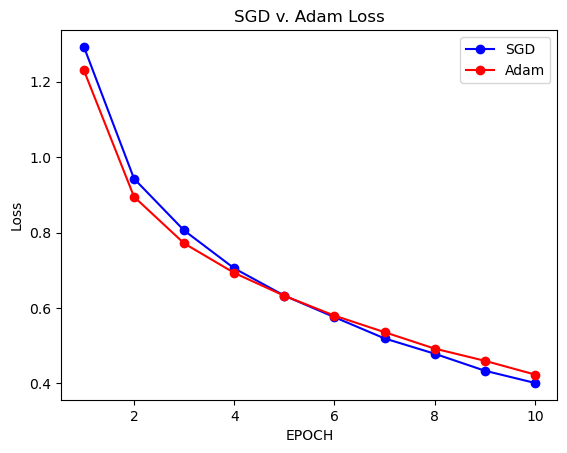

In [27]:
model_adam = CIFAR_CNN().to(device)
model_adam.train()

# Training setup
EPOCHS = 10
loss_fnc = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_adam.parameters(), lr=0.001)
loss_adam = []

# Training loop
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for images, labels in train_loader:
        # move the tensors to the gpu (mps)
        images = images.to(device)
        labels = labels.to(device)

        # perform inference
        y_hat = model_adam(images)

        # compute loss
        loss = loss_fnc(y_hat, labels)
        epoch_loss += loss.item()
        
        # back propagation
        optimizer.zero_grad()  # zeroes out the gradients -> pytorch accumulates the gradients so we have to zero them
        loss.backward()        # perform back propagation -> calculates the gradients
        optimizer.step()       # updates the parameters

    loss_adam.append(epoch_loss / len(train_loader))

# put the model in inference mode
model_adam.eval()
correct = 0
total = 0


with torch.no_grad(): # disables gradient computation (speeds things up)
    for images, labels in test_loader:

        # perform the inference
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_adam(images)
        predictions = outputs.argmax(dim=1)  # pick the class with highest logit
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        


print("=" * 50 + "\n")
print("CIFAR_CNN_Adam:")
print(f"Accuracy: {correct/total}")



x_data = [i for i in range(1, EPOCHS + 1)]


# plot the loss for each epoch

plt.plot(x_data, loss_sgd, marker='o', color='blue', label='SGD')
plt.plot(x_data, loss_adam, marker='o', color='red', label='Adam')

plt.xlabel('EPOCH')
plt.ylabel('Loss')
plt.title('SGD v. Adam Loss')
plt.legend()
plt.show()


---
## Exercise 4: Transfer Learning with MobileNetV2

Fine-tune a pretrained MobileNetV2 — this is directly relevant to Models 2 & 3 in your project.

In [3]:
# 4a. Feature extraction (Model 2 style):
#   - Load pretrained MobileNetV2: models.mobilenet_v2(weights='IMAGENET1K_V1')
#   - Freeze all parameters: for param in model.parameters(): param.requires_grad = False
#   - Replace the classifier head: model.classifier[1] = nn.Linear(1280, 10)
#   - Train only the head on CIFAR-10 for 5 epochs
#   - Note: CIFAR-10 is 32x32, MobileNetV2 expects 224x224. Resize in transforms or use AdaptiveAvgPool.
#
# 4b. Fine-tuning (Model 3 style):
#   - Unfreeze all parameters
#   - Train with a lower LR (e.g., 0.0001) for 5 more epochs
#   - Compare accuracy: frozen vs fine-tuned

# Your code here:

# 4a.

transform_mobilenet = transforms.Compose([                                                                                                                     
  transforms.Resize(224),                                                                                                                                  
  transforms.ToTensor(),                                                                                                                                     
  transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))                                                                                 
])                                                                                                                                                             

train_data_mobile = datasets.CIFAR10('data', train=True, transform=transform_mobilenet)                                                                        
test_data_mobile = datasets.CIFAR10('data', train=False, transform=transform_mobilenet)                                                                      
train_loader_mobile = DataLoader(train_data_mobile, batch_size=16, shuffle=True)
test_loader_mobile = DataLoader(test_data_mobile, batch_size=64)

model = models.mobilenet_v2(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(1280, 10)

# Model setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device found!")
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU.")

model.to(device)

model.train()

# Training setup
EPOCHS = 5
loss_fnc = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(EPOCHS):
     for i, (images, labels) in enumerate(train_loader_mobile):
        # move the tensors to the gpu (mps)
        images = images.to(device)
        labels = labels.to(device)

        # perform inference
        y_hat = model(images)

        # compute loss
        loss = loss_fnc(y_hat, labels)

        if i % 100 == 0:
              print(f"Epoch {epoch}, batch {i}/{len(train_loader_mobile)}, loss: {loss.item():.4f}")
         
        # back propagation
        optimizer.zero_grad()  # zeroes out the gradients -> pytorch accumulates the gradients so we have to zero them
        loss.backward()        # perform back propagation -> calculates the gradients
        optimizer.step()       # updates the parameters

# Set model to evaluation mode for inference
model.eval()

# put the model in inference mode
correct = 0
total = 0


with torch.no_grad(): # disables gradient computation (speeds things up)
    for images, labels in test_loader_mobile:
        
        # perform the inference
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)  # pick the class with highest logit
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        


print("=" * 50 + "\n")
print("MobileNetV2:")
print(f"Accuracy: {correct/total}")

MPS device found!
Epoch 0, batch 0/3125, loss: 2.4727
Epoch 0, batch 100/3125, loss: 1.2190
Epoch 0, batch 200/3125, loss: 1.1309
Epoch 0, batch 300/3125, loss: 0.9589
Epoch 0, batch 400/3125, loss: 0.6616
Epoch 0, batch 500/3125, loss: 0.7651
Epoch 0, batch 600/3125, loss: 1.1195
Epoch 0, batch 700/3125, loss: 1.2269
Epoch 0, batch 800/3125, loss: 0.4756
Epoch 0, batch 900/3125, loss: 0.9743
Epoch 0, batch 1000/3125, loss: 0.7131
Epoch 0, batch 1100/3125, loss: 1.3342
Epoch 0, batch 1200/3125, loss: 0.9265
Epoch 0, batch 1300/3125, loss: 0.7555
Epoch 0, batch 1400/3125, loss: 0.8850
Epoch 0, batch 1500/3125, loss: 0.4627
Epoch 0, batch 1600/3125, loss: 0.9278
Epoch 0, batch 1700/3125, loss: 1.1827
Epoch 0, batch 1800/3125, loss: 0.9613
Epoch 0, batch 1900/3125, loss: 0.9250
Epoch 0, batch 2000/3125, loss: 0.7378
Epoch 0, batch 2100/3125, loss: 1.1269
Epoch 0, batch 2200/3125, loss: 1.1000
Epoch 0, batch 2300/3125, loss: 0.7234
Epoch 0, batch 2400/3125, loss: 1.1597
Epoch 0, batch 2500

In [4]:
# 4b

# unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True


# Training setup
EPOCHS = 5
loss_fnc = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(EPOCHS):
    for i, (images, labels) in enumerate(train_loader_mobile):
        # move the tensors to the gpu (mps)
        images = images.to(device)
        labels = labels.to(device)

        # perform inference
        y_hat = model(images)

        # compute loss
        loss = loss_fnc(y_hat, labels)

        if i % 100 == 0:
              print(f"Epoch {epoch}, batch {i}/{len(train_loader_mobile)}, loss: {loss.item():.4f}")

        # back propagation
        optimizer.zero_grad()  # zeroes out the gradients -> pytorch accumulates the gradients so we have to zero them
        loss.backward()        # perform back propagation -> calculates the gradients
        optimizer.step()       # updates the parameters

# Set model to evaluation mode for inference
model.eval()


# put the model in inference mode
correct = 0
total = 0


with torch.no_grad(): # disables gradient computation (speeds things up)
    for i, (images, labels) in enumerate(test_loader_mobile):

        # perform the inference
        images = images.to(device)
        labels = labels.to(device)

        if i % 100 == 0:
              print(f"Batch {i}/{len(test_loader_mobile)}")

        outputs = model(images)
        predictions = outputs.argmax(dim=1)  # pick the class with highest logit
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        


print("=" * 50 + "\n")
print("MobileNetV2 Finetuned:")
print(f"Accuracy: {correct/total}")

Epoch 0, batch 0/3125, loss: 0.2685
Epoch 0, batch 100/3125, loss: 2.3934
Epoch 0, batch 200/3125, loss: 2.5590
Epoch 0, batch 300/3125, loss: 2.3336
Epoch 0, batch 400/3125, loss: 2.6523
Epoch 0, batch 500/3125, loss: 2.2910
Epoch 0, batch 600/3125, loss: 2.5595
Epoch 0, batch 700/3125, loss: 2.5354
Epoch 0, batch 800/3125, loss: 2.4617
Epoch 0, batch 900/3125, loss: 2.6783
Epoch 0, batch 1000/3125, loss: 2.4784
Epoch 0, batch 1100/3125, loss: 2.5079
Epoch 0, batch 1200/3125, loss: 2.3350
Epoch 0, batch 1300/3125, loss: 2.3656
Epoch 0, batch 1400/3125, loss: 2.3887
Epoch 0, batch 1500/3125, loss: 2.6252
Epoch 0, batch 1600/3125, loss: 2.9165
Epoch 0, batch 1700/3125, loss: 2.3745
Epoch 0, batch 1800/3125, loss: 2.4893
Epoch 0, batch 1900/3125, loss: 2.3246
Epoch 0, batch 2000/3125, loss: 2.3382
Epoch 0, batch 2100/3125, loss: 2.4169
Epoch 0, batch 2200/3125, loss: 2.7302
Epoch 0, batch 2300/3125, loss: 3.0347
Epoch 0, batch 2400/3125, loss: 2.8599
Epoch 0, batch 2500/3125, loss: 2.544

## Exercise 5: Data Augmentation

Add augmentation to your training pipeline and measure the effect.

In [6]:
# Update transform_train to include augmentation:
#   transforms.RandomHorizontalFlip(),
#   transforms.RandomCrop(32, padding=4),
#   transforms.ColorJitter(brightness=0.2, contrast=0.2),
#
# Retrain your CNN (from exercise 2) with augmented data for 10 epochs
# Compare test accuracy: with vs without augmentation
# Augmentation should help generalization, especially if the model was overfitting

transform_augmented = transforms.Compose([                                                                                                                     
    transforms.RandomHorizontalFlip(),                                                                                                                         
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),                                                                                                      
    transforms.ToTensor(),                                                                                                                                     
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])                

transform_test = transforms.Compose([
    transforms.ToTensor(),                                                                                                                                     
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_data = datasets.CIFAR10('data', train=True, transform=transform_augmented)                                                                        
test_data = datasets.CIFAR10('data', train=False, transform=transform_test)                                                                      
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)



# Your code here:
class CIFAR_CNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        # init the convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_features=64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # init the linear layers
        self.linear1 = nn.Linear(64 * 4 * 4, 128)
        self.dropout = nn.Dropout(p=0.2)
        self.linear2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        # conv2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        # conv3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        # linear layers
        x = x.view(x.size(0), -1) # flatten x
        x = self.linear1(x)
        x = self.dropout(x)
        x = self.relu(x)
        x = self.linear2(x)

        return x

# Model setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device found!")
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU.")

model = CIFAR_CNN().to(device)

model.train()

# Training setup
EPOCHS = 10
loss_fnc = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(EPOCHS):
    for images, labels in train_loader:
        # move the tensors to the gpu (mps)
        images = images.to(device)
        labels = labels.to(device)

        # perform inference
        y_hat = model(images)

        # compute loss
        loss = loss_fnc(y_hat, labels)

        # back propagation
        optimizer.zero_grad()  # zeroes out the gradients -> pytorch accumulates the gradients so we have to zero them
        loss.backward()        # perform back propagation -> calculates the gradients
        optimizer.step()       # updates the parameters


# put the model in inference mode
model.eval()
correct = 0
total = 0

with torch.no_grad(): # disables gradient computation (speeds things up)
    for images, labels in test_loader:

        # perform the inference
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)  # pick the class with highest logit
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        


print("=" * 50 + "\n")
print("CNN with:")
print(f"Accuracy: {correct/total}")




MPS device found!

CNN with:
Accuracy: 0.6207
